<a href="https://colab.research.google.com/github/ascot119-rgb/Alex-s-Projects/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Precision: 0.6571428571428571
Recall: 0.5476190476190477
F1 Score: 0.5974025974025974


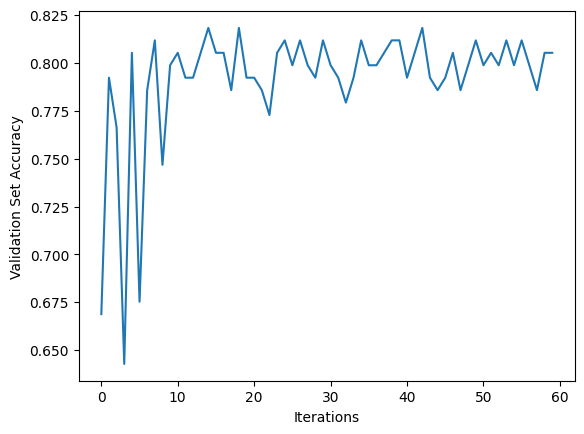

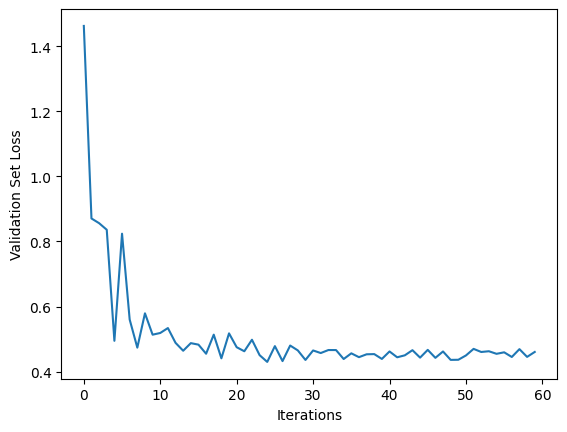

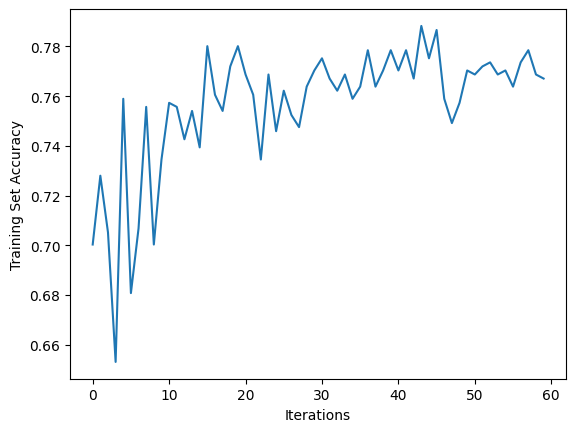

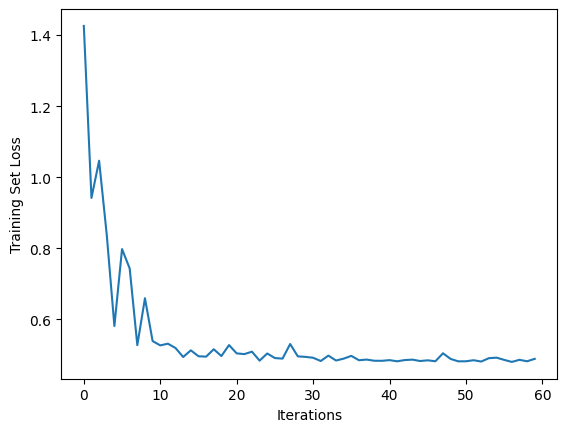

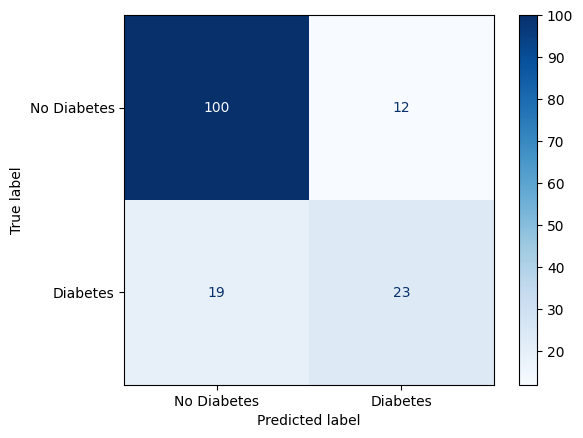

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rnd
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import log_loss
from decimal import Decimal

filepath = "/content/diabetes.csv"

df = pd.read_csv(filepath)

def getprecision(predict, y):
  p = 0
  tp = 0
  for i in range(len(predict)):
    if predict[i] == 1:
      p += 1
    if predict[i] == 1 and y[i] == 1:
      tp += 1
  return tp/p

def getrecall(predict, y):
  rp = 0
  tp = 0
  for i in range(len(predict)):
    if y[i] == 1:
      rp += 1
    if predict[i] == 1 and y[i] == 1:
      tp += 1
  return tp/rp
def getf1(precision, recall):
  return 2*precision*recall/(precision+recall)

scaler_X = StandardScaler() # Scaler for input features


y = df.values[:, -1]
paramnames = df.columns.values[:]
params = np.zeros(len(df.values[0]))
inputdata = df.values[:, :-1]

inputdata = np.array(inputdata)
inputdata = scaler_X.fit_transform(inputdata) # Fit and transform input features


validation_indices = np.arange(rnd.randint(0,4), len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)

index = np.arange(0, len(inputdata[0]))

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

v_accuracy_over_time=[]
v_loss_over_time=[]
t_accuracy_over_time=[]
t_loss_over_time=[]

clf = SGDClassifier(max_iter=1, tol=2e-5, loss='log_loss', alpha = 0.001, warm_start=True)
result = clf.partial_fit(inputdata, y, classes=np.unique(y))

for i in range(60):
  v_accuracy_over_time.append(result.score(validationdata, validationy))
  v_loss_over_time.append(log_loss(validationy, result.predict_proba(validationdata)))
  t_accuracy_over_time.append(result.score(inputdata, y))
  t_loss_over_time.append(log_loss(y, result.predict_proba(inputdata)))
  result = clf.partial_fit(inputdata, y)



#precision = getprecision(result.predict(inputdata), y)
#recall = getrecall(result.predict(inputdata), y)
#print(f"Precision: {precision}")
#print(f"Recall: {recall}")

precision = getprecision(result.predict(validationdata), validationy)
recall = getrecall(result.predict(validationdata), validationy)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {getf1(precision, recall)}")

class_names = ["No Diabetes", "Diabetes"]

plt.plot(v_accuracy_over_time)
plt.xlabel("Iterations")
plt.ylabel("Validation Set Accuracy")
plt.show()

plt.plot(v_loss_over_time)
plt.xlabel("Iterations")
plt.ylabel("Validation Set Loss")
plt.show()

plt.plot(t_accuracy_over_time)
plt.xlabel("Iterations")
plt.ylabel("Training Set Accuracy")
plt.show()

plt.plot(t_loss_over_time)
plt.xlabel("Iterations")
plt.ylabel("Training Set Loss")
plt.show()

disp = ConfusionMatrixDisplay.from_estimator(
      result,
      validationdata,
      validationy,
      display_labels=class_names,
      cmap=plt.cm.Blues,
      normalize=None,
 )



Precision: 1.0
Recall: 0.98
F1 Score: 0.98989898989899


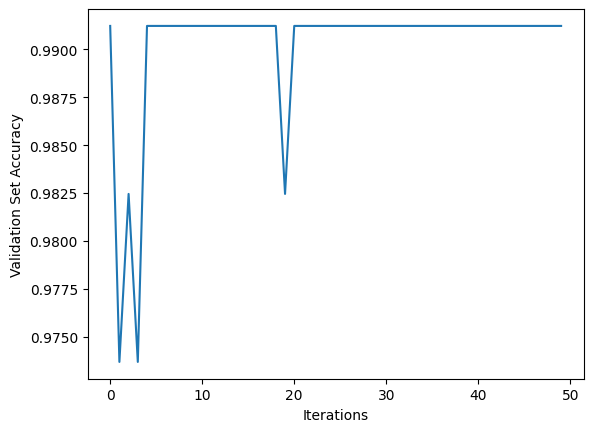

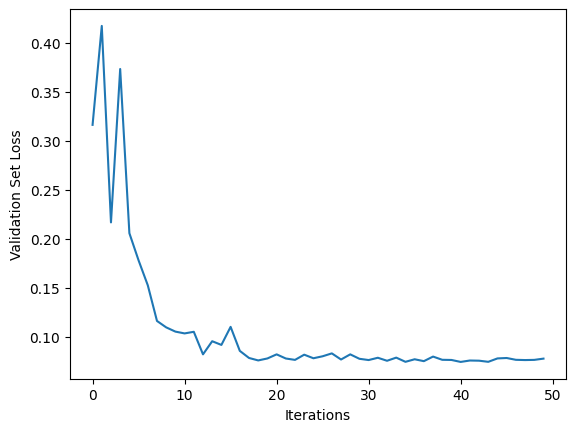

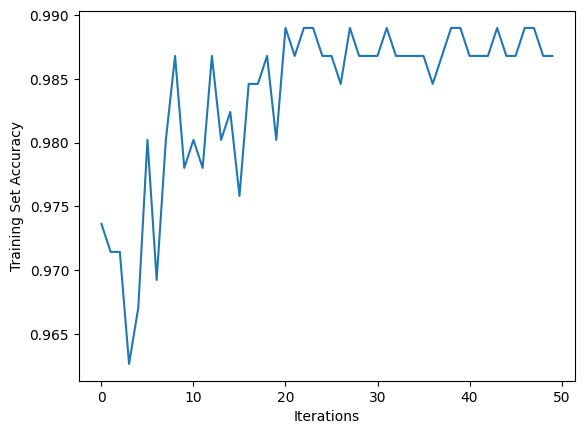

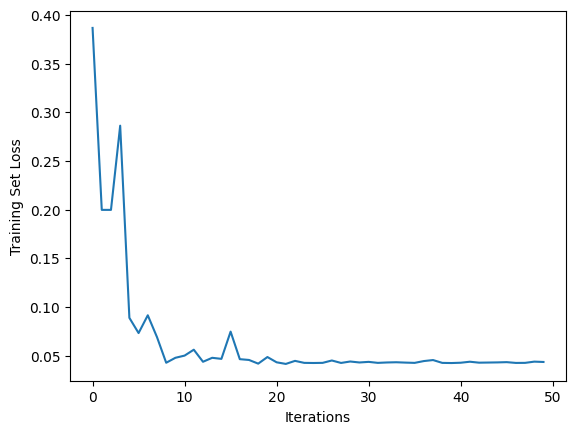

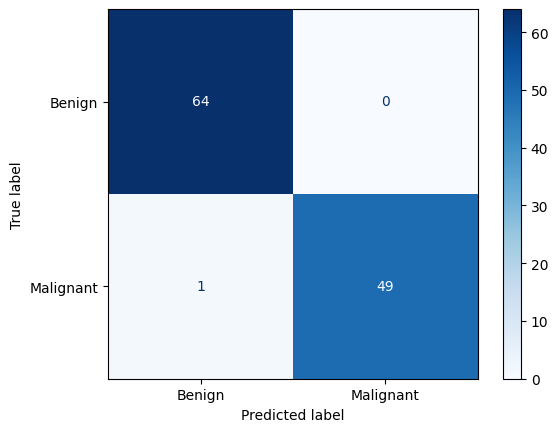

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random as rnd
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from decimal import Decimal
from sklearn.utils.multiclass import type_of_target

filepath = "/content/Cancer.csv"

df = pd.read_csv(filepath)

def getprecision(predict, y):
  p = 0
  tp = 0
  for i in range(len(predict)):
    if predict[i] == 1:
      p += 1
    if predict[i] == 1 and y[i] == 1:
      tp += 1
  return tp/p

def getrecall(predict, y):
  rp = 0
  tp = 0
  for i in range(len(predict)):
    if y[i] == 1:
      rp += 1
    if predict[i] == 1 and y[i] == 1:
      tp += 1
  return tp/rp
def getf1(precision, recall):
  return 2*precision*recall/(precision+recall)

scaler_X = StandardScaler() # Scaler for input features


y = df.values[:, 1]
for i in range(len(y)):
  if y[i] == "M":
    y[i] = 1
  else:
    y[i] = 0
paramnames = df.columns.values[:]
params = np.zeros(len(df.values[0]))
inputdata = df.values[:, 2:-1]

inputdata = np.array(inputdata)
inputdata = scaler_X.fit_transform(inputdata) # Fit and transform input features

validation_indices = np.arange(rnd.randint(0,4), len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)

index = np.arange(0, len(inputdata[0]))

y=y.astype(int)

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

v_accuracy_over_time=[]
v_loss_over_time=[]
t_accuracy_over_time=[]
t_loss_over_time=[]

clf = SGDClassifier(max_iter=1, tol=2e-6, loss='log_loss', alpha = 0.001, warm_start=True)
result = clf.partial_fit(inputdata, y, classes=np.unique(y))

for i in range(50):
  v_accuracy_over_time.append(result.score(validationdata, validationy))
  v_loss_over_time.append(log_loss(validationy, result.predict_proba(validationdata)))
  t_accuracy_over_time.append(result.score(inputdata, y))
  t_loss_over_time.append(log_loss(y, result.predict_proba(inputdata)))
  result = clf.partial_fit(inputdata, y)

precision = getprecision(result.predict(validationdata), validationy)
recall = getrecall(result.predict(validationdata), validationy)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {getf1(precision, recall)}")

plt.plot(v_accuracy_over_time)
plt.xlabel("Iterations")
plt.ylabel("Validation Set Accuracy")
plt.show()

plt.plot(v_loss_over_time)
plt.xlabel("Iterations")
plt.ylabel("Validation Set Loss")
plt.show()

plt.plot(t_accuracy_over_time)
plt.xlabel("Iterations")
plt.ylabel("Training Set Accuracy")
plt.show()

plt.plot(t_loss_over_time)
plt.xlabel("Iterations")
plt.ylabel("Training Set Loss")
plt.show()

class_names = ["Benign", "Malignant"]

disp = ConfusionMatrixDisplay.from_estimator(
      result,
      validationdata,
      validationy,
      display_labels=class_names,
      cmap=plt.cm.Blues,
      normalize=None,
 )